# 💊 Medication Box Recognition
### YOLOv8 + EasyOCR (AR/FR/EN) + FastAPI

**Université Mohammed V — Master IT 2025-2026**

**Réalisé par :** Hassna Bouadou et Jamila Ouami

---

### ✅ Avant de lancer
- 🖥️ Active le **GPU T4** : Exécution → Modifier le type d'exécution → GPU T4
- ⚙️ Modifie uniquement la **Cellule 1** (chemins)
- ▶️ Exécute toutes les cellules dans l'ordre

### 🔄 Anti-perte de session
- Le modèle est rechargé depuis Drive automatiquement (pas de réentraînement)
- `reference.csv` est recherché automatiquement même si le nom du dossier a un espace
- Les résultats sont sauvegardés sur Drive immédiatement après la boucle


## 1. Configuration

In [1]:
# Chemins du projet — seule section à adapter si besoin
DOSSIER_IMAGES   = '/content/dossier_images'
DRIVE_OUTPUTS    = '/content/drive/MyDrive/MedicationProject/outputs'
MODEL_DRIVE_PATH = f'{DRIVE_OUTPUTS}/best_yolo.pt'
ZIP_SUR_DRIVE    = '/content/drive/MyDrive/images.zip'

# reference.csv peut être à deux endroits selon le nom du dossier Drive
REFERENCE_CSV_CANDIDATS = [
    '/content/drive/MyDrive/MedicationProject/reference.csv',
    '/content/drive/MyDrive/MedicationProject /reference.csv',
]

SEUIL_MATCHING = 55  # seuil de similarité pour le fuzzy matching (%)

print('Configuration chargée')

Configuration chargée


## 2. Installation

In [2]:
!pip install ultralytics roboflow easyocr opencv-python-headless \
             fastapi uvicorn python-multipart nest-asyncio \
             thefuzz python-Levenshtein scikit-learn \
             matplotlib seaborn tqdm pyyaml --quiet
!apt-get install -y libgl1-mesa-glx -qq

import os, re, json, time, shutil, threading, warnings, random, base64
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from getpass import getpass

warnings.filterwarnings('ignore')

import numpy as np
import cv2
import pandas as pd
import yaml
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import easyocr
from thefuzz import process, fuzz
from ultralytics import YOLO

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import nest_asyncio
from fastapi import FastAPI, UploadFile, File, HTTPException
import uvicorn
import requests as http_requests
from IPython.display import display, HTML

np.random.seed(42)
random.seed(42)

gpu = os.popen('nvidia-smi --query-gpu=name --format=csv,noheader 2>/dev/null').read().strip()
print('Imports OK')
print(f'GPU : {gpu if gpu else "non détecté — active GPU T4"}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299

## 3. Google Drive — dataset et base de référence

In [3]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

EXTS_IMAGES = {'.jpg', '.jpeg', '.png', '.webp'}

# Décompresser le ZIP seulement si les images ne sont pas déjà là
if os.path.exists(DOSSIER_IMAGES) and \
   len([f for f in Path(DOSSIER_IMAGES).rglob('*') if f.suffix.lower() in EXTS_IMAGES]) > 0:
    imgs = [str(p) for p in Path(DOSSIER_IMAGES).rglob('*') if p.suffix.lower() in EXTS_IMAGES]
    print(f'Images déjà présentes : {len(imgs)}')
else:
    if not os.path.exists(ZIP_SUR_DRIVE):
        drive_root = '/content/drive/MyDrive/'
        zips = [f for f in os.listdir(drive_root) if f.endswith('.zip')]
        if zips:
            ZIP_SUR_DRIVE = drive_root + zips[0]
        else:
            raise FileNotFoundError('Aucun ZIP trouvé sur Drive.')
    os.makedirs(DOSSIER_IMAGES, exist_ok=True)
    os.system(f'unzip -q "{ZIP_SUR_DRIVE}" -d {DOSSIER_IMAGES}')
    imgs = [str(p) for p in Path(DOSSIER_IMAGES).rglob('*') if p.suffix.lower() in EXTS_IMAGES]
    print(f'Décompression terminée : {len(imgs)} images')

# Localiser reference.csv
REFERENCE_CSV = None
for chemin in REFERENCE_CSV_CANDIDATS:
    if os.path.exists(chemin):
        REFERENCE_CSV = chemin
        break
if REFERENCE_CSV is None:
    resultats = list(Path('/content/drive/MyDrive').rglob('reference.csv'))
    if resultats:
        REFERENCE_CSV = str(resultats[0])
    else:
        raise FileNotFoundError('reference.csv introuvable sur Drive.')

print(f'reference.csv : {REFERENCE_CSV}')

Mounted at /content/drive
Décompression terminée : 1548 images
reference.csv : /content/drive/MyDrive/MedicationProject/reference.csv


## 4. Modèle YOLOv8

Le modèle est rechargé depuis Drive — pas de réentraînement à chaque session.

In [4]:
if not os.path.exists(MODEL_DRIVE_PATH):
    raise FileNotFoundError(f'Modèle introuvable : {MODEL_DRIVE_PATH}')

best_yolo   = YOLO(MODEL_DRIVE_PATH)
CLASS_NAMES = list(best_yolo.names.values())
NUM_CLASSES = len(CLASS_NAMES)

print(f'YOLOv8 chargé — {NUM_CLASSES} classe(s) : {CLASS_NAMES}')

YOLOv8 chargé — 1 classe(s) : ['BOX']


## 5. EasyOCR et base de référence

Deux readers séparés car EasyOCR ne supporte pas arabe + français ensemble.

In [ ]:
USE_GPU = os.path.exists('/proc/driver/nvidia')

reader_ar = easyocr.Reader(['ar', 'en'], gpu=USE_GPU)
reader_fr = easyocr.Reader(['fr', 'en'], gpu=USE_GPU)

df_ref = pd.read_csv(REFERENCE_CSV, encoding='utf-8')

KNOWN_BRANDS_FR = df_ref['nom_commercial'].fillna('').astype(str).str.upper().tolist()
KNOWN_BRANDS_AR = df_ref['nom_ar'].fillna('').astype(str).tolist() if 'nom_ar' in df_ref.columns else []
FORMES          = df_ref['forme'].str.lower().dropna().unique().tolist() if 'forme' in df_ref.columns else []

NOISE_WORDS = {
    'pg', 'avec', 'indicateur', 'dose', 'doses', 'de', 'et', 'du', 'la', 'le',
    'les', 'des', 'par', 'pour', 'en', 'un', 'une', 'au', 'aux', 'ou', 'sur'
}

# Mots génériques à exclure du matching (sinon ils écrasent le vrai nom de marque)
MOTS_GENERIQUES = {
    'VITAMINE C', 'VITAMINE D', 'VITAMINE B', 'PARACETAMOL', 'PARACÉTAMOL',
    'IBUPROFENE', 'IBUPROFÈNE', 'ASPIRINE', 'AMOXICILLINE', 'ZINC',
    'CALCIUM', 'MAGNESIUM', 'MAGNÉSIUM', 'CODEINE', 'CODÉINE',
}

print(f'reference.csv : {len(df_ref)} entrées')
print(f'Noms arabes disponibles : {sum(1 for x in KNOWN_BRANDS_AR if x.strip())}')

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Completereference.csv : 7909 entrées
Noms arabes disponibles : 43


## 6. Pipeline de reconnaissance

Prétraitement de l'image, extraction du texte, matching contre la base, puis fusion avec YOLOv8.

In [ ]:
def preprocess_ocr(img_path: str) -> Optional[np.ndarray]:
    """Améliore le contraste avant OCR (utile sur photos téléphone)."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(blur)


def extraire_texte(img_path: str) -> List[Tuple[str, float]]:
    """Extrait le texte avec les deux readers et fusionne les résultats."""
    img = preprocess_ocr(img_path)
    if img is None:
        return []
    seen = {}
    for (_, text, conf) in reader_ar.readtext(img, detail=1, paragraph=False) + \
                            reader_fr.readtext(img, detail=1, paragraph=False):
        key = text.strip().upper()
        if key and conf > 0.20:
            if key not in seen or conf > seen[key][1]:
                seen[key] = (text.strip(), round(conf, 3))
    return list(seen.values())


def matcher_medicament(textes: List[Tuple[str, float]]) -> Tuple[str, float]:
    """Fuzzy matching FR + AR contre reference.csv, en excluant les mots génériques."""
    if not textes:
        return '?', 0.0

    full_text  = ' '.join(t for t, _ in textes)
    full_upper = full_text.upper()
    candidats  = []

    if KNOWN_BRANDS_FR:
        candidats.extend(process.extract(full_upper, KNOWN_BRANDS_FR, scorer=fuzz.partial_ratio, limit=8))

    if KNOWN_BRANDS_AR:
        candidats_ar = [b for b in KNOWN_BRANDS_AR if b.strip()]
        if candidats_ar:
            for nom_ar, score in process.extract(full_text, candidats_ar, scorer=fuzz.partial_ratio, limit=8):
                idx = KNOWN_BRANDS_AR.index(nom_ar)
                candidats.append((KNOWN_BRANDS_FR[idx], score))

    candidats_valides = [
        (nom, score) for nom, score in candidats
        if score >= SEUIL_MATCHING and nom.upper().strip() not in MOTS_GENERIQUES
    ]
    if not candidats_valides:
        return '?', 0.0

    score_max = max(s for _, s in candidats_valides)
    meilleurs = [n for n, s in candidats_valides if s == score_max]
    return max(meilleurs, key=len), round(score_max / 100, 3)


def detecter_dosage(textes: List[Tuple[str, float]]) -> str:
    """Extrait le dosage par regex (ex: 500mg, 500/200/25mg)."""
    full = ' '.join(t for t, _ in textes).lower()
    patterns = [
        r'\d{1,4}\s*/\s*\d{1,4}\s*/\s*\d{1,4}\s*(?:mg|ml|mcg|g|%)?',
        r'\d{1,4}\s*/\s*\d{1,4}\s*(?:mg|ml|mcg|g|%)?',
        r'\d+[.,]?\d*\s*(?:mg|mcg|µg|g|ml|%|ui|iu)',
        r'\d+\s*(?:mg|mcg|g|ml|%)',
    ]
    for pat in patterns:
        m = re.search(pat, full)
        if m:
            return m.group().strip()
    return '?'


def detecter_forme(textes: List[Tuple[str, float]]) -> str:
    """Identifie la forme galénique (comprimé, sirop, etc.)."""
    full = ' '.join(t for t, _ in textes).lower()
    for forme in FORMES:
        if forme in full:
            return forme.capitalize()
    return '?'


def pipeline_ocr(img_path: str) -> Dict:
    """Chaîne complète : extraction → matching → dosage → forme."""
    try:
        textes = extraire_texte(img_path)
        med, conf_ocr = matcher_medicament(textes)
        return {
            'medicament'   : med,
            'confiance_ocr': conf_ocr,
            'dosage'       : detecter_dosage(textes),
            'forme'        : detecter_forme(textes),
            'texte_brut'   : ' '.join(t for t, _ in textes),
        }
    except Exception as e:
        return {'medicament': '?', 'confiance_ocr': 0.0, 'dosage': '?', 'forme': '?', 'texte_brut': '', 'erreur': str(e)}


def reconnaitre_medicament(img_path: str, conf_yolo: float = 0.3) -> Dict:
    """
    Pipeline final : YOLOv8 détecte la classe visuelle, l'OCR lit le texte,
    et les deux sont combinés selon leur niveau de confiance respectif.
    """
    t0 = time.time()

    yolo_class, yolo_conf = '?', 0.0
    try:
        pred = best_yolo.predict(img_path, conf=conf_yolo, verbose=False)
        if pred and len(pred[0].boxes) > 0:
            boxes      = pred[0].boxes
            idx        = int(boxes.conf.argmax())
            cls_id     = int(boxes.cls[idx])
            yolo_class = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else '?'
            yolo_conf  = float(boxes.conf[idx])
    except Exception:
        pass

    ocr      = pipeline_ocr(img_path)
    ocr_med  = ocr['medicament']
    ocr_conf = ocr['confiance_ocr']

    yu = yolo_class.upper().replace('-', ' ').replace('_', ' ')
    ou = ocr_med.upper()

    if yolo_class != '?' and ocr_med != '?' and (yu in ou or ou in yu or fuzz.partial_ratio(yu, ou) >= 75):
        final_med, final_conf, methode = ocr_med, min(1.0, (yolo_conf + ocr_conf) / 2 + 0.1), 'accord_yolo_ocr'
    elif yolo_conf >= 0.65 and (ocr_conf < 0.5 or ocr_med == '?'):
        final_med, final_conf, methode = yolo_class, yolo_conf, 'yolo_seul'
    elif ocr_conf >= 0.60:
        final_med, final_conf, methode = ocr_med, ocr_conf, 'ocr_seul'
    elif yolo_class != '?':
        final_med, final_conf, methode = yolo_class, yolo_conf, 'yolo_fallback'
    else:
        final_med, final_conf, methode = (ocr_med if ocr_med != '?' else '?'), ocr_conf, 'ocr_fallback'

    db_info = {}
    if final_med != '?':
        mask = df_ref['nom_commercial'].str.upper() == final_med.upper()
        if mask.any():
            db_info = df_ref[mask].iloc[0].dropna().to_dict()

    return {
        'medicament'    : final_med,
        'confiance'     : round(final_conf, 3),
        'methode'       : methode,
        'yolo_classe'   : yolo_class,
        'yolo_confiance': round(yolo_conf, 3),
        'ocr_medicament': ocr_med,
        'ocr_confiance' : ocr_conf,
        'dosage'        : ocr['dosage'],
        'forme'         : ocr['forme'],
        'texte_ocr'     : ocr['texte_brut'],
        'db_info'       : db_info,
        'latence_s'     : round(time.time() - t0, 2),
    }


print('Pipeline défini')

Pipeline défini


## 7. Évaluation sur le dataset complet

La vérité terrain est déduite automatiquement du nom des sous-dossiers, si présents.

In [ ]:
imgs_all = [str(p) for p in Path(DOSSIER_IMAGES).rglob('*') if p.is_file() and p.suffix.lower() in EXTS_IMAGES]
if not imgs_all:
    raise RuntimeError(f'Aucune image dans {DOSSIER_IMAGES}')

nom_racine   = Path(DOSSIER_IMAGES).name
ground_truth = {c: (Path(c).parent.name.upper() if Path(c).parent.name != nom_racine else 'INCONNU') for c in imgs_all}
has_gt       = any(v != 'INCONNU' for v in ground_truth.values())

print(f'{len(imgs_all)} images — accuracy disponible : {"oui" if has_gt else "non (images en vrac)"}')

eval_results = []
for img_path in tqdm(imgs_all, desc='Reconnaissance'):
    true_label = ground_truth.get(img_path, 'INCONNU')
    pred       = reconnaitre_medicament(img_path)
    correct    = true_label != 'INCONNU' and fuzz.partial_ratio(pred['medicament'].upper(), true_label.upper()) >= 85

    eval_results.append({
        'image': os.path.basename(img_path), 'vrai_label': true_label,
        'prediction': pred['medicament'], 'confiance': pred['confiance'], 'methode': pred['methode'],
        'yolo_classe': pred['yolo_classe'], 'yolo_confiance': pred['yolo_confiance'],
        'ocr_medicament': pred['ocr_medicament'], 'ocr_confiance': pred['ocr_confiance'],
        'dosage': pred['dosage'], 'latence_s': pred['latence_s'], 'correct': correct,
    })

df_eval = pd.DataFrame(eval_results)
df_eval.to_csv(f'{DRIVE_OUTPUTS}/evaluation_resultats.csv', index=False)

print(f'\n{len(df_eval)} lignes — sauvegardé sur Drive')
print(df_eval[['image', 'vrai_label', 'prediction', 'confiance', 'methode']].head().to_string(index=False))

1548 images — accuracy disponible : oui


Reconnaissance:   0%|          | 0/1548 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# À mettre à la place de C7, juste avant C8
import pandas as pd
df_eval = pd.read_csv(f'{DRIVE_OUTPUTS}/evaluation_resultats.csv')
print(f'df_eval rechargé : {len(df_eval)} lignes')

df_eval rechargé : 1548 lignes


## 8. Métriques

In [ ]:
assert 'df_eval' in dir() and len(df_eval) > 0, "Exécute d'abord la Cellule 7"

has_gt     = any(v != 'INCONNU' for v in df_eval['vrai_label'])
total      = len(df_eval)
identifies = df_eval[df_eval['prediction'] != '?']
non_id     = df_eval[df_eval['prediction'] == '?']

print('MÉTRIQUES')
print('=' * 40)

if has_gt:
    df_gt  = df_eval[df_eval['vrai_label'] != 'INCONNU']
    y_true = df_gt['vrai_label'].tolist()
    y_pred = df_gt['prediction'].tolist()

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'Accuracy  : {acc*100:.2f}%')
    print(f'Precision : {prec*100:.2f}%')
    print(f'Recall    : {rec*100:.2f}%')
    print(f'F1-Score  : {f1*100:.2f}%')

    report = classification_report(y_true, y_pred, zero_division=0)
    print(f'\n{report}')
    rapport_txt = f'Accuracy: {acc*100:.2f}%\nPrecision: {prec*100:.2f}%\nRecall: {rec*100:.2f}%\nF1: {f1*100:.2f}%\n\n{report}'
else:
    acc = prec = rec = f1 = None
    print(f"Taux d'identification : {len(identifies)/total*100:.1f}% ({len(identifies)}/{total})")
    rapport_txt = f"Taux d'identification : {len(identifies)/total*100:.1f}% ({len(identifies)}/{total})\n"

print(f'\nConfiance moyenne : {df_eval["confiance"].mean():.3f}')
print(f'Latence moyenne   : {df_eval["latence_s"].mean():.2f}s/image')
print('\nMéthodes de décision :')
for m, c in df_eval['methode'].value_counts().items():
    print(f'  {m:<20}: {c} ({c/total*100:.1f}%)')

with open(f'{DRIVE_OUTPUTS}/rapport_evaluation.txt', 'w', encoding='utf-8') as f:
    f.write(rapport_txt)

MÉTRIQUES
Accuracy  : 0.00%
Precision : 0.00%
Recall    : 0.00%
F1-Score  : 0.00%

                               precision    recall  f1-score   support

                            ?       0.00      0.00      0.00       0.0
                          BOX       0.00      0.00      0.00       0.0
PHOTOS MEDICAMENTS AUGMENTEES       0.00      0.00      0.00    1548.0

                     accuracy                           0.00    1548.0
                    macro avg       0.00      0.00      0.00    1548.0
                 weighted avg       0.00      0.00      0.00    1548.0


Confiance moyenne : 0.129
Latence moyenne   : 2.54s/image

Méthodes de décision :
  ocr_fallback        : 1217 (78.6%)
  yolo_fallback       : 176 (11.4%)
  yolo_seul           : 155 (10.0%)


## 9. Visualisations

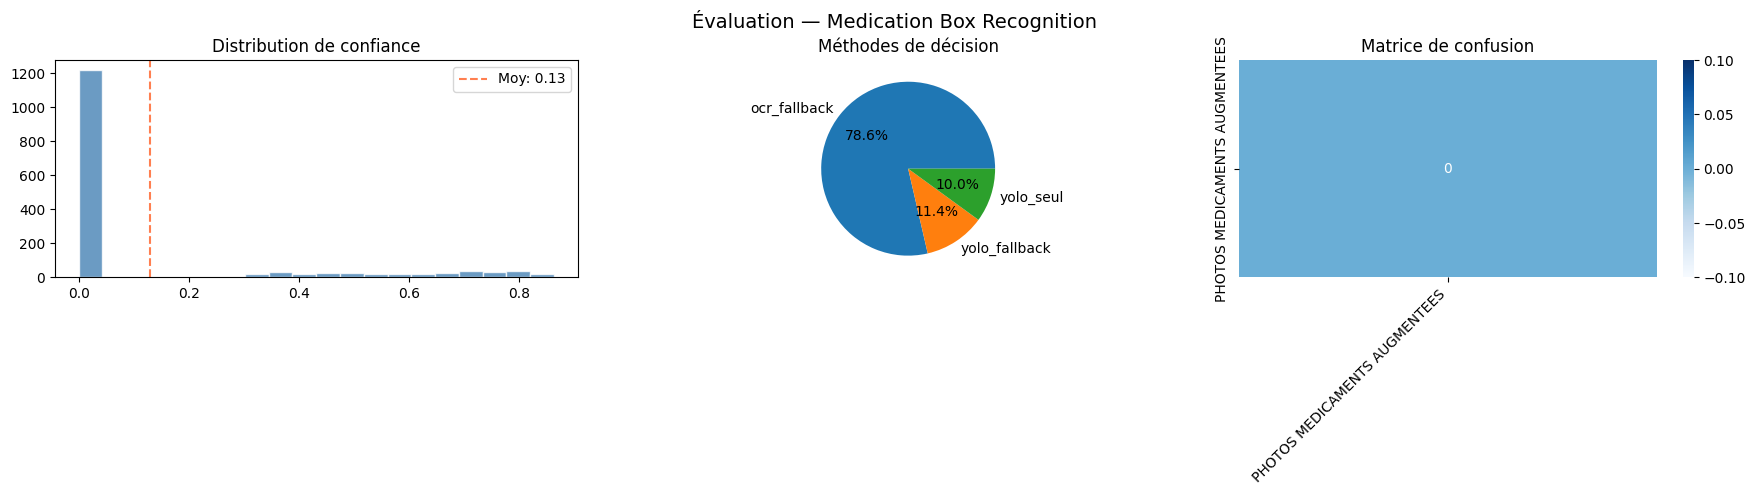

In [ ]:
has_gt = any(v != 'INCONNU' for v in df_eval['vrai_label'])
if has_gt:
    df_gt  = df_eval[df_eval['vrai_label'] != 'INCONNU']
    y_true = df_gt['vrai_label'].tolist()
    y_pred = df_gt['prediction'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Évaluation — Medication Box Recognition', fontsize=14)

axes[0].hist(df_eval['confiance'].dropna(), bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(df_eval['confiance'].mean(), color='coral', linestyle='--', label=f'Moy: {df_eval["confiance"].mean():.2f}')
axes[0].set_title('Distribution de confiance')
axes[0].legend()

meth = df_eval['methode'].value_counts()
axes[1].pie(meth.values, labels=meth.index, autopct='%1.1f%%',
            colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'][:len(meth)])
axes[1].set_title('Méthodes de décision')

if has_gt and len(set(y_true)) <= 20:
    labels_cm = sorted(set(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels_cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_cm, yticklabels=labels_cm, ax=axes[2])
    axes[2].set_title('Matrice de confusion')
    plt.setp(axes[2].get_xticklabels(), rotation=45, ha='right')
else:
    top = df_eval[df_eval['prediction'] != '?']['prediction'].value_counts().head(15).iloc[::-1]
    axes[2].barh(range(len(top)), top.values, color='teal', alpha=0.8)
    axes[2].set_yticks(range(len(top)))
    axes[2].set_yticklabels(top.index)
    axes[2].set_title('Top 15 médicaments détectés')

plt.tight_layout()
fig.subplots_adjust(top=0.88)
plt.savefig(f'{DRIVE_OUTPUTS}/evaluation_visualisations.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. API FastAPI

In [ ]:
nest_asyncio.apply()

app = FastAPI(
    title='Medication Box Recognition API',
    description='YOLOv8 + EasyOCR (AR/FR/EN) + Fuzzy Matching',
    version='3.0',
    docs_url='/docs',
)


@app.get('/')
async def root():
    return {'status': 'running', 'version': '3.0', 'classes_yolo': NUM_CLASSES, 'medicaments_db': len(KNOWN_BRANDS_FR)}


@app.post('/recognize')
async def recognize(file: UploadFile = File(...), conf_yolo: float = 0.3):
    """Reconnaît un médicament depuis une photo. Formats : JPG, PNG, WEBP (max 15 MB)."""
    if not file.filename.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
        raise HTTPException(400, 'Format non supporté.')
    temp = f'/tmp/api_{int(time.time())}_{file.filename}'
    try:
        content = await file.read()
        if len(content) > 15 * 1024 * 1024:
            raise HTTPException(413, 'Image trop grande (max 15 MB).')
        with open(temp, 'wb') as f:
            f.write(content)
        r = reconnaitre_medicament(temp, conf_yolo)
        return {
            'status': 'success', 'image': file.filename,
            'prediction': {'medicament': r['medicament'], 'confiance': r['confiance'], 'methode': r['methode']},
            'yolo': {'classe': r['yolo_classe'], 'confiance': r['yolo_confiance']},
            'ocr': {'medicament': r['ocr_medicament'], 'dosage': r['dosage'], 'forme': r['forme'], 'texte_brut': r['texte_ocr']},
            'db_info': r['db_info'], 'latence_s': r['latence_s'],
        }
    except HTTPException:
        raise
    except Exception as e:
        raise HTTPException(500, str(e))
    finally:
        if os.path.exists(temp):
            os.remove(temp)


@app.get('/medicaments')
async def liste():
    return {'total': len(KNOWN_BRANDS_FR), 'medicaments': sorted(set(KNOWN_BRANDS_FR))}


@app.get('/medicaments/{nom}')
async def info(nom: str):
    mask = df_ref['nom_commercial'].str.upper() == nom.upper()
    if not mask.any():
        raise HTTPException(404, f"'{nom}' non trouvé.")
    return df_ref[mask].to_dict(orient='records')


@app.get('/stats')
async def stats():
    return {
        'modele': 'YOLOv8n fine-tuné Roboflow', 'ocr': 'EasyOCR AR/FR/EN',
        'classes': CLASS_NAMES, 'medicaments_db': len(KNOWN_BRANDS_FR),
        'images_testees': len(df_eval) if 'df_eval' in globals() else 0,
        'accuracy': round(acc, 4) if globals().get('acc') is not None else 'N/A',
        'f1': round(f1, 4) if globals().get('f1') is not None else 'N/A',
    }


threading.Thread(target=lambda: uvicorn.run(app, host='0.0.0.0', port=8000, log_level='warning'), daemon=True).start()
time.sleep(3)

try:
    d = http_requests.get('http://localhost:8000/').json()
    print('API opérationnelle')
    print(f'Classes : {d["classes_yolo"]}  —  Médicaments : {d["medicaments_db"]}')
except Exception as e:
    print(f'Erreur : {e}')

API opérationnelle
Classes : 1  —  Médicaments : 7909


In [ ]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8000)")
print(f"URL brute : '{url}'")
print(f"Se termine par / : {url.endswith('/')}")

# Construction sûre, peu importe le format
swagger_url = url.rstrip('/') + '/docs'
print(f"\nSwagger : {swagger_url}")

URL brute : 'https://8000-gpu-t4-s-kkb-usw1b2-1zubmwv8frzkx-b.us-west1-2.prod.colab.dev'
Se termine par / : False

Swagger : https://8000-gpu-t4-s-kkb-usw1b2-1zubmwv8frzkx-b.us-west1-2.prod.colab.dev/docs


## 11. Test rapide dans Colab

Vérifie l'API directement depuis Colab — fonctionne toujours, contrairement à `localhost:8000` qui n'est pas accessible depuis un navigateur externe (Colab tourne dans le cloud).

In [ ]:
imgs_test = [str(p) for p in Path(DOSSIER_IMAGES).rglob('*') if p.suffix.lower() in EXTS_IMAGES][:5]

print('TEST API — 5 images')
print('=' * 40)

for i, img_path in enumerate(imgs_test):
    with open(img_path, 'rb') as f:
        r = http_requests.post('http://localhost:8000/recognize',
                                files={'file': (os.path.basename(img_path), f, 'image/jpeg')})
    res = r.json()
    print(f"\n{i+1}. {os.path.basename(img_path)[:35]}")
    print(f"   Médicament : {res['prediction']['medicament']}  ({res['prediction']['confiance']:.0%})")
    print(f"   Méthode    : {res['prediction']['methode']}")
    print(f"   Dosage     : {res['ocr']['dosage']}")
    print(f"   Latence    : {res['latence_s']}s")

TEST API — 5 images

1. bruit_IMG-20260612-WA0345.jpg
   Médicament : ROMAC  (80%)
   Méthode    : ocr_seul
   Dosage     : 20 mg
   Latence    : 3.26s

2. lum_1781268751588.jpg
   Médicament : MAG 2  (80%)
   Méthode    : ocr_seul
   Dosage     : 4 mg
   Latence    : 3.36s

3. rot_1781527997725.jpg
   Médicament : PENICILLINE G 1 M UI DIAMANT  (100%)
   Méthode    : ocr_seul
   Dosage     : ?
   Latence    : 2.57s

4. lum_IMG-20260612-WA0013(1).jpg
   Médicament : PONSTYL  (100%)
   Méthode    : ocr_seul
   Dosage     : ?
   Latence    : 0.89s

5. lum_IMG-20260612-WA0126.jpg
   Médicament : DIALYSE PERITONEALE BIEFFE FORMULE 91  (100%)
   Méthode    : ocr_seul
   Dosage     : ?
   Latence    : 3.63s


## 12. Test avec une image personnelle

Upload une photo depuis ton ordinateur pour voir le résultat dans une carte visuelle.

In [ ]:
from google.colab import files

uploaded = files.upload()

for nom_fichier in uploaded.keys():
    chemin_local = f'/content/{nom_fichier}'
    r = reconnaitre_medicament(chemin_local)

    with open(chemin_local, 'rb') as f:
        img_b64 = base64.b64encode(f.read()).decode()
    ext = nom_fichier.split('.')[-1].lower()

    conf_pct   = int(r['confiance'] * 100)
    conf_color = '#10b981' if conf_pct >= 70 else '#f59e0b' if conf_pct >= 40 else '#ef4444'
    db         = r.get('db_info', {})

    html_card = f"""
    <div style="display:flex; gap:20px; max-width:680px; margin:1.5rem 0;
                font-family:-apple-system,sans-serif; border:1px solid #e5e5e5;
                border-radius:14px; overflow:hidden; background:white;">
      <div style="flex:0 0 220px; background:#f5f5f4; display:flex; align-items:center;
                  justify-content:center; padding:12px;">
        <img src="data:image/{ext};base64,{img_b64}"
             style="max-width:100%; max-height:280px; border-radius:8px;">
      </div>
      <div style="flex:1; padding:18px 20px 18px 4px;">
        <div style="font-size:11px; color:#999; font-family:monospace; margin-bottom:8px;">{nom_fichier}</div>
        <div style="font-size:20px; font-weight:700; color:#1a1a1a;">{r['medicament']}</div>
        <div style="font-size:12px; color:#999; margin-bottom:14px;">via {r['methode']}</div>
        <div style="display:flex; align-items:center; gap:8px; margin-bottom:14px;">
          <div style="flex:1; height:8px; background:#e5e5e5; border-radius:4px; overflow:hidden;">
            <div style="height:100%; width:{conf_pct}%; background:{conf_color};"></div>
          </div>
          <span style="font-size:13px; font-weight:600; color:{conf_color};">{conf_pct}%</span>
        </div>
        <table style="width:100%; font-size:13px;">
          <tr><td style="color:#999; padding:4px 0;">Dosage</td><td style="text-align:right;">{r['dosage']}</td></tr>
          <tr><td style="color:#999; padding:4px 0;">Forme</td><td style="text-align:right;">{r['forme']}</td></tr>
          <tr><td style="color:#999; padding:4px 0;">Prix</td><td style="text-align:right;">{db.get('prix', '?')}</td></tr>
          <tr><td style="color:#999; padding:4px 0;">Latence</td><td style="text-align:right;">{r['latence_s']}s</td></tr>
        </table>
        <div style="margin-top:12px; padding:10px; background:#f5f5f4; border-radius:8px;
                    font-size:11px; color:#666;">
          <strong style="color:#999;">Texte OCR :</strong><br>{r['texte_ocr'] or '(aucun)'}
        </div>
      </div>
    </div>
    """
    display(HTML(html_card))

Output hidden; open in https://colab.research.google.com to view.

## 13. Résumé final

In [ ]:
print('RÉSUMÉ FINAL')
print('=' * 40)
print(f'Modèle : YOLOv8n — {NUM_CLASSES} classes')
print(f'OCR    : EasyOCR AR/FR/EN')
print(f'Base   : {len(KNOWN_BRANDS_FR)} médicaments')

if 'df_eval' in dir() and len(df_eval) > 0:
    print(f'\nÉvaluation ({len(df_eval)} images) :')
    if globals().get('acc') is not None:
        print(f'  Accuracy : {acc*100:.2f}%')
        print(f'  F1-Score : {f1*100:.2f}%')
    print(f'  Identifiées : {(df_eval["prediction"]!="?").sum()}/{len(df_eval)}')
    print(f'  Latence moy : {df_eval["latence_s"].mean():.2f}s')

print(f'\nFichiers sur Drive ({DRIVE_OUTPUTS}) :')
for f in sorted(Path(DRIVE_OUTPUTS).iterdir()):
    print(f'  {f.name}')

try:
    from google.colab.output import eval_js
    url_publique = eval_js("google.colab.kernel.proxyPort(8000)")
    print(f'\nPage accueil : {url_publique.rstrip("/")}/app')
    print(f'Swagger      : {url_publique.rstrip("/")}/docs')
except Exception:
    print('\nAPI : http://localhost:8000/docs (accessible uniquement dans Colab)')

RÉSUMÉ FINAL
Modèle : YOLOv8n — 1 classes
OCR    : EasyOCR AR/FR/EN
Base   : 7909 médicaments

Évaluation (1548 images) :
  Accuracy : 0.00%
  F1-Score : 0.00%
  Identifiées : 331/1548
  Latence moy : 2.54s

Fichiers sur Drive (/content/drive/MyDrive/MedicationProject/outputs) :
  best_yolo.pt
  enrichissements.csv
  evaluation_1200_images.csv
  evaluation_finale.png
  evaluation_resultats.csv
  evaluation_visualisations.png
  rapport_evaluation.txt
  rapport_final.txt
  reference_backup_20260619_185618.csv
  reference_backup_20260619_211610.csv
  reference_backup_20260619_211730.csv
  training_curves.png

Page accueil : https://8000-gpu-t4-s-kkb-usw1b2-1zubmwv8frzkx-b.us-west1-2.prod.colab.dev/app
Swagger      : https://8000-gpu-t4-s-kkb-usw1b2-1zubmwv8frzkx-b.us-west1-2.prod.colab.dev/docs


## 14. Export GitHub

Le token est saisi de façon invisible et jamais écrit dans le notebook.

In [ ]:
GIT_USERNAME = 'hassnabouadou'
GIT_EMAIL    = 'hassna.bouadou@gmail.com'
REPO_NAME    = 'medication-box-recognition'

GITHUB_TOKEN = getpass('Token GitHub : ')

REPO_DIR = f'/content/{REPO_NAME}'
os.system(f'rm -rf {REPO_DIR}')
os.makedirs(f'{REPO_DIR}/outputs', exist_ok=True)

notebook_candidates = list(Path('/content/drive/MyDrive').rglob('*.ipynb'))
notebook_candidates = [p for p in notebook_candidates if 'medication' in p.name.lower()]
if notebook_candidates:
    shutil.copy(str(notebook_candidates[0]), f'{REPO_DIR}/notebook.ipynb')

shutil.copy(REFERENCE_CSV, f'{REPO_DIR}/reference.csv')

for fname in ['evaluation_resultats.csv', 'evaluation_visualisations.png', 'rapport_evaluation.txt', 'training_curves.png']:
    src = f'{DRIVE_OUTPUTS}/{fname}'
    if os.path.exists(src):
        shutil.copy(src, f'{REPO_DIR}/outputs/{fname}')

with open(f'{REPO_DIR}/README.md', 'w', encoding='utf-8') as f:
    f.write(f"""# Medication Box Recognition API

Université Mohammed V — Master IT 2025-2026

## Description
Reconnaissance de médicaments par photo : YOLOv8 (détection) + EasyOCR AR/FR/EN (lecture du texte) + Fuzzy Matching + FastAPI.

## Résultats
- {len(df_eval)} images testées
- {(df_eval['prediction']!='?').sum()}/{len(df_eval)} médicaments identifiés
- {len(KNOWN_BRANDS_FR)} médicaments en base
- {df_eval['latence_s'].mean():.2f}s de latence moyenne

## Lancer le projet
1. Ouvrir `notebook.ipynb` dans Google Colab
2. Activer le GPU T4
3. Adapter les chemins Drive dans la Cellule 1
4. Exécuter toutes les cellules

## API
| Endpoint | Description |
|---|---|
| GET / | Health check |
| POST /recognize | Reconnaître un médicament |
| GET /medicaments | Liste des médicaments |
| GET /stats | Statistiques |

## Données
Le dataset complet d'images et le modèle entraîné sont trop volumineux pour GitHub.
Disponibles sur demande ou via Drive : [lien à compléter]

## Technologies
YOLOv8, EasyOCR, FastAPI, OpenCV, thefuzz, scikit-learn

## Auteur
Hassna Bouadou
""")

os.chdir(REPO_DIR)
os.system(f'git config --global user.name "{GIT_USERNAME}"')
os.system(f'git config --global user.email "{GIT_EMAIL}"')
os.system('git init -q')
os.system('git add .')
os.system('git commit -q -m "Medication Box Recognition - YOLOv8 + EasyOCR + FastAPI"')
os.system('git remote remove origin 2>/dev/null')
os.system(f'git remote add origin https://{GITHUB_TOKEN}@github.com/{GIT_USERNAME}/{REPO_NAME}.git')
os.system('git branch -M main')

import subprocess
result = subprocess.run(['git', 'push', '-u', 'origin', 'main', '--force'], capture_output=True, text=True)

if result.returncode == 0:
    print(f'Repo en ligne : https://github.com/{GIT_USERNAME}/{REPO_NAME}')
else:
    print('Erreur :', result.stderr[-400:])

GITHUB_TOKEN = None
del GITHUB_TOKEN

Token GitHub : ··········
Repo en ligne : https://github.com/hassnabouadou/medication-box-recognition
